# What are the most optimal skills to learn for Data Analysts?

In [85]:
# importing libraries
import ast 
import pandas as pd 
from datasets import load_dataset 
import matplotlib.pyplot as plt 
import seaborn as sns

# loading the dataset
dataset = load_dataset('lukebarousse/data_jobs') 
df = dataset['train'].to_pandas() 

# data cleanup 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date']) 
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [86]:
df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

In [87]:
df_DA_India = df_DA_India.dropna(subset=['salary_year_avg'])

df_DA_India_exploded = df_DA_India.explode('job_skills')

df_DA_India_exploded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
11412,50400.0,python
11412,50400.0,sql
11412,50400.0,aws
11412,50400.0,azure
11412,50400.0,excel


In [96]:
df_DA_skills = df_DA_India_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count':'skill_count', 'median':'median_salary'})

DA_job_count = len(df_DA_India)

df_DA_skills['skill_perc'] = df_DA_skills['skill_count'] / DA_job_count * 100

skill_percent = 6

df_DA_skills_w_high_demand = df_DA_skills[df_DA_skills['skill_perc'] > skill_percent]

df_DA_skills_w_high_demand

,skill_count,median_salary,skill_perc
job_skills,,,
sql,46,96050.00,48.936170
excel,39,98500.00,41.489362
python,36,96050.00,38.297872
tableau,20,108087.50,21.276596
r,18,79200.00,19.148936
power bi,17,111175.00,18.085106
azure,15,93600.00,15.957447
aws,12,79200.00,12.765957
oracle,11,79200.00,11.702128


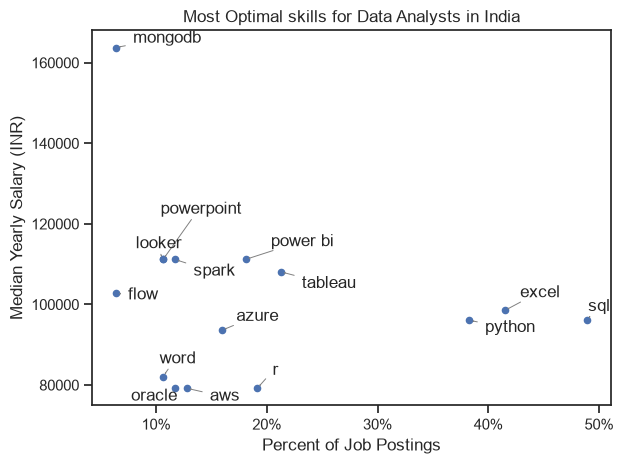

In [100]:
from adjustText import adjust_text 

df_DA_skills_w_high_demand.plot(kind='scatter', x='skill_perc', y='median_salary') 

texts = [] 
for i, txt in enumerate(df_DA_skills_w_high_demand.index): 
  texts.append(plt.text(df_DA_skills_w_high_demand['skill_perc'].iloc[i], df_DA_skills_w_high_demand['median_salary'].iloc[i], " "+ txt)) 
  
adjust_text(texts,expand=(1.3, 1.5),force_text=(1.2, 1.5),force_static=(1.0, 1.2),arrowprops=dict(arrowstyle='->', color='gray', lw=0.7))
  
plt.xlabel('Percent of Job Postings') 
plt.ylabel('Median Yearly Salary (INR)') 
plt.title('Most Optimal skills for Data Analysts in India') 

from matplotlib.ticker import PercentFormatter
ax= plt.gca()
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout() 
plt.show()